<div style="
  position: relative;
  background: #0f1a1c;
  border-radius: 25px;
  padding: 60px 35px;
  text-align: center;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0 0 50px rgba(16,185,129,0.2), 0 10px 40px rgba(0,0,0,0.6);
  border: 2px solid #10b981;
  background-image:
    radial-gradient(1.5px 1.5px at 20px 30px, rgba(255,255,255,0.9), transparent),
    radial-gradient(1px 1px at 70px 75px, rgba(16,185,129,0.9), transparent),
    radial-gradient(1.5px 1.5px at 130px 40px, rgba(255,255,255,0.7), transparent),
    radial-gradient(1px 1px at 190px 105px, rgba(45,212,191,0.85), transparent),
    radial-gradient(1.5px 1.5px at 250px 60px, rgba(255,255,255,0.85), transparent),
    radial-gradient(1px 1px at 310px 95px, rgba(16,185,129,0.7), transparent),
    radial-gradient(1.5px 1.5px at 45px 135px, rgba(255,255,255,0.6), transparent),
    radial-gradient(1px 1px at 350px 25px, rgba(45,212,191,0.8), transparent),
    radial-gradient(1.5px 1.5px at 225px 145px, rgba(255,255,255,0.9), transparent);
  background-repeat: no-repeat;
  background-color: #0f1a1c;
">

  <div style="
    display:inline-block;
    padding: 6px 22px;
    border: 1px solid #10b981;
    border-radius: 30px;
    color:#2dd4bf;
    letter-spacing:3px;
    font-size:13px;
    margin-bottom:28px;
    box-shadow: 0 0 15px rgba(16,185,129,0.4);
  ">
    MINI-PROJET
  </div>

  <h1 style="
    font-size: 32px;
    margin:0 0 18px 0;
    color: #2dd4bf;
    text-shadow: 0 0 20px rgba(45,212,191,0.5);
    font-weight: 800;
  ">
    Préparation de données tabulaires
  </h1>

  <p style="font-size: 17px; color: #a7f3d0; letter-spacing: 0.5px; max-width: 78%; margin: 5px auto 0 auto; line-height: 1.7;">
    <strong>Contexte :</strong> capteurs IoT de bâtiments intelligents. Objectif : nettoyer <code style="background:rgba(16,185,129,0.12); padding:2px 8px; border-radius:5px; color:#5eead4;">smart_building_raw.csv</code> et produire un dataset prêt pour le Machine Learning (prédiction de consommation / détection d'anomalies).
  </p>

  <div style="width:55%; margin:30px auto; height:1px; background:linear-gradient(90deg, transparent, #10b981, #2dd4bf, #10b981, transparent);"></div>

  <h3 style="font-size: 22px; color: #ffffff; margin-bottom: 5px;">
    Harouna MBAYE
  </h3>
  <p style="font-size: 14px; color: #a7f3d0;">
    SONATEL ACADEMY </br>Master 2 Business Intelligence FST - UCAD
  </p>

  <blockquote style="
    font-family: 'Georgia', 'Palatino Linotype', serif;
    font-style: italic;
    font-size: 17px;
    color: #f5deb3;
    max-width: 70%;
    margin: 30px auto 10px auto;
    padding: 15px 25px;
    border-left: 4px solid #10b981;
    background: rgba(16,185,129,0.06);
    border-radius: 8px;
  ">
    « Des données propres valent mieux qu'un modèle complexe. »
  </blockquote>

</div>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [19]:
PALETTE = ["#2E4057", "#D68C45", "#7A9E7E", "#B4436C"]
sns.set_theme(style="whitegrid", palette=PALETTE)
pd.set_option("display.max_columns", None)

## Partie 1: Exploration des données

In [5]:
# 1) Charger les données CSV
df = pd.read_csv("../data/smart_building_raw.csv")
# 2) Afficher les premières lignes du dataset
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


In [6]:
# 3) Afficher les dernières lignes du dataset
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


In [7]:
# 4) Combien d'observations contient le dataset ?
# 5) Combien de variables possède le dataset ?
n_lignes, n_colonnes = df.shape
print("Observations :", n_lignes)
print("Variables :", n_colonnes)

Observations : 507
Variables : 14


### Types de variables

In [8]:
# 6) Identifier les variables numériques
colonnes_numeriques = ["temperature", "humidite", "co2", "occupation", "consommation_kwh"]
# 7) Identifier les variables catégorielles
colonnes_categorielles = ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine", "alerte"]
# 8) Identifier les dates
colonnes_dates = ["date"]
# 9) Identifier les identifiants
colonnes_identifiants = ["id_mesure"]

print("Numériques :", colonnes_numeriques)
print("Catégorielles :", colonnes_categorielles)
print("Dates :", colonnes_dates)
print("Identifiants :", colonnes_identifiants)

Numériques : ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']
Catégorielles : ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']
Dates : ['date']
Identifiants : ['id_mesure']


In [ ]:
# 10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles
df[colonnes_numeriques].describe()

*(11) Y a-t-il des variables potentiellement problématiques ?*

**Variables potentiellement problématiques :** `humidite` (bornes 0-100 à vérifier), `temperature` et `consommation_kwh` (valeurs extrêmes suspectes), `occupation` (ne doit pas être négative), `date` (formats invalides), `type_batiment` et `mode_climatisation` (catégories mal orthographiées / casse différente).

### Incohérences

*(12) Pour les données incohérentes*

In [9]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print("Dates invalides :", df["date"].isna().sum())

# 12a) rechercher des valeurs telles que humidité < 0
print("Humidité < 0 :", (df["humidite"] < 0).sum())
# 12b) rechercher des valeurs telles que humidité > 100
print("Humidité > 100 :", (df["humidite"] > 100).sum())
# 12c) rechercher des valeurs telles que température extrêmement élevée
print("Température > 60°C :", (df["temperature"] > 60).sum())
# 12c) (suite) rechercher des valeurs telles que température extrêmement basse
print("Température < -20°C :", (df["temperature"] < -20).sum())
# 12d) rechercher des valeurs telles que négative (occupation)
print("Occupation < 0 :", (df["occupation"] < 0).sum())
# 12e) rechercher des valeurs telles que consommation négative
print("Consommation < 0 :", (df["consommation_kwh"] < 0).sum())

Dates invalides : 5
Humidité < 0 : 3
Humidité > 100 : 7
Température > 60°C : 4
Température < -20°C : 2
Occupation < 0 : 5
Consommation < 0 : 4


In [10]:
# 12f) Si une valeur est manifestement erronée et qu'on ne peut pas retrouver sa vraie valeur, la transformer en valeur manquante
# Valeurs physiquement impossibles -> transformées en valeurs manquantes (on ne peut pas deviner la vraie valeur)
df.loc[(df["humidite"] < 0) | (df["humidite"] > 100), "humidite"] = np.nan
df.loc[(df["temperature"] > 60) | (df["temperature"] < -20), "temperature"] = np.nan
df.loc[df["occupation"] < 0, "occupation"] = np.nan
df.loc[df["consommation_kwh"] < 0, "consommation_kwh"] = np.nan

print("Incohérences corrigées.")

Incohérences corrigées.


In [11]:
# 12g) rechercher des valeurs telles que catégories mal orthographiées
for colonne in ["type_batiment", "mode_climatisation"]:
    print(colonne, ":", sorted(df[colonne].dropna().unique().tolist()))

type_batiment : [' Bureau ', ' UNIVERSITÉ', 'BUREAU', 'Bureau', 'Bureu', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'bureau', 'centre commercial', 'ecole', 'entrepot', 'hôpital ', 'ÉCOLE', 'École']
mode_climatisation : ['BOOST', 'Boost', 'Eco', 'Normal', 'Normal ', 'normal', 'normale']


In [ ]:
# 12h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse
# Normalisation du texte : suppression des espaces, mise en minuscule
for colonne in ["type_batiment", "mode_climatisation", "jour_semaine"]:
    df[colonne] = df[colonne].str.strip().str.lower()

# 12g) (suite) uniformisation des catégories mal orthographiées
# Uniformisation des catégories mal orthographiées
corrections_type_batiment = {
    "ecole": "école",
    "entrepot": "entrepôt",
    "bureu": "bureau",
}
df["type_batiment"] = df["type_batiment"].replace(corrections_type_batiment)

corrections_climatisation = {
    "normale": "normal",
}
df["mode_climatisation"] = df["mode_climatisation"].replace(corrections_climatisation)

# Remise en forme (première lettre en majuscule) pour l'affichage
for colonne in ["type_batiment", "mode_climatisation", "jour_semaine"]:
    df[colonne] = df[colonne].str.capitalize()

for colonne in ["type_batiment", "mode_climatisation"]:
    print(colonne, ":", sorted(df[colonne].dropna().unique().tolist()))

### Valeurs manquantes

In [15]:
# 13a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne
manquants = df.isnull().sum()
pourcentage_manquants = (manquants / len(df) * 100).round(2)
tableau_manquants = pd.DataFrame({"nb_manquants": manquants, "pourcentage": pourcentage_manquants})
tableau_manquants = tableau_manquants[tableau_manquants["nb_manquants"] > 0].sort_values("nb_manquants", ascending=False)
# 13b) Quelle variable possède le plus de valeurs manquantes ? -> la première ligne du tableau trié ci-dessous
tableau_manquants

,nb_manquants,pourcentage
humidite,21,4.14
temperature,18,3.55
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
date,5,0.99
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79


*(13c) Quelle stratégie utiliser pour les valeurs manquantes ?*

**Stratégie retenue :**
- *(13d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?* On ne supprime pas toutes les lignes avec valeurs manquantes : le volume de données perdu serait trop important et cela pourrait introduire un biais.
- *(13e) Dans quels cas utiliser la moyenne ? / 13f) Quand préférer la médiane ?* Variables numériques à distribution symétrique -> **moyenne** ; en présence de valeurs extrêmes -> **médiane** (plus robuste aux outliers). Ici on utilisera la médiane pour toutes les variables numériques par prudence.
- *(13g) Comment traiter une variable catégorielle ?* Variables catégorielles -> imputation par le **mode** (valeur la plus fréquente).

### Doublons

*(14) Pour les doublons*

In [16]:
# 14a) Identifier les doublons
nb_doublons = df.duplicated().sum()
print("Nombre de doublons :", nb_doublons)
# 14b) Afficher les doublons
df[df.duplicated(keep=False)].sort_values("id_mesure")

Nombre de doublons : 7


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
192,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.3,952.0,89.0,247.6,normal,Normal,mardi,Oui
117,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.3,952.0,89.0,247.6,normal,Normal,mardi,Oui
9,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,NaN,479.0,64.0,145.0,normal,Normal,jeudi,Non
123,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,NaN,479.0,64.0,145.0,normal,Normal,jeudi,Non
23,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.3,1034.0,74.0,199.2,normal,Panne,vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.3,1034.0,74.0,199.2,normal,Panne,vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,bureau,B,27.5,27.2,359.0,33.0,185.8,normal,Normal,vendredi,Non
464,1320,2025-03-21 18:00:00,B7,bureau,B,27.5,27.2,359.0,33.0,185.8,normal,Normal,vendredi,Non
238,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.0,868.0,62.0,172.5,eco,Normal,vendredi,Non
418,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.0,868.0,62.0,172.5,eco,Normal,vendredi,Non


In [17]:
# 14c) Sont-ils réellement identiques ?
# Ce sont des lignes strictement identiques sur toutes les colonnes -> véritables doublons
# 14d) Supprimer les doublons réellement identifiés
df = df.drop_duplicates()
# 14e) Vérifier la suppression
print("Doublons restants :", df.duplicated().sum())
print("Nouvelle taille :", df.shape)

Doublons restants : 0
Nouvelle taille : (500, 14)


### Distributions, dispersion et valeurs aberrantes

*(15) Pour la température, l'humidité, le CO₂ et la consommation, identifier visuellement : a) les distributions, b) la dispersion, c) les valeurs extrêmes, d) les valeurs potentiellement aberrantes*

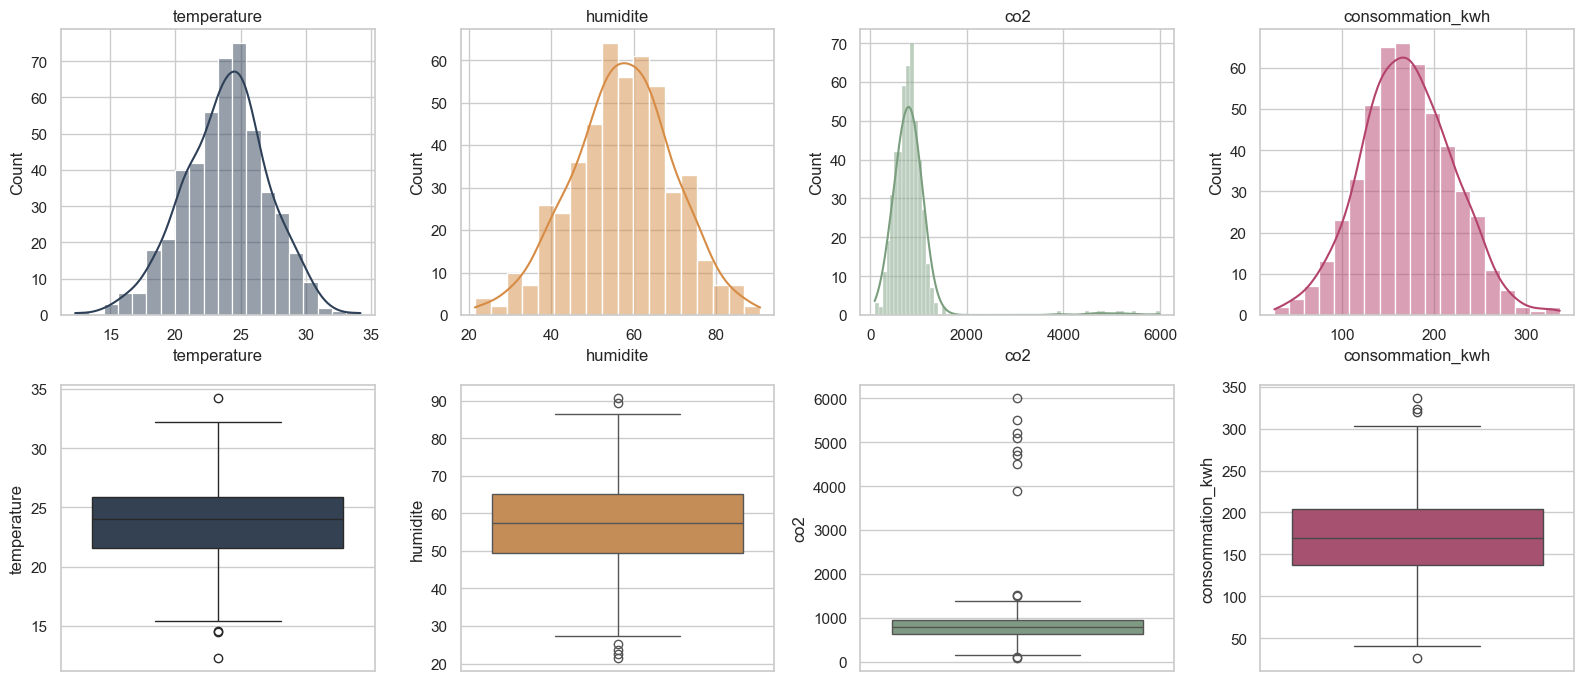

In [20]:
# 15) Visualisation (histogrammes + boxplots) pour identifier distributions, dispersion, valeurs extrêmes et aberrantes
colonnes_a_visualiser = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, colonne in enumerate(colonnes_a_visualiser):
    sns.histplot(df[colonne].dropna(), kde=True, ax=axes[0, i], color=PALETTE[i % len(PALETTE)])
    axes[0, i].set_title(colonne)
    sns.boxplot(y=df[colonne], ax=axes[1, i], color=PALETTE[i % len(PALETTE)])
plt.tight_layout()
plt.show()

*(15a, 15b, 15c) Lecture des distributions, de la dispersion et des valeurs extrêmes*

**Lecture rapide :** `co2` et `consommation_kwh` sont plutôt étalés à droite (asymétrie positive) avec quelques valeurs extrêmes visibles sur les boxplots ; `temperature` et `humidite` sont plus symétriques.

*(16) Quelle stratégie utiliser pour les valeurs aberrantes ?*

**Stratégie pour les valeurs aberrantes :** ne pas les supprimer aveuglément (elles peuvent correspondre à de vraies anomalies, utiles pour détecter des situations anormales). On les repère avec la méthode de l'IQR mais on les garde dans le dataset, en les signalant.

In [21]:
# 15d) identifier les valeurs potentiellement aberrantes (méthode de l'IQR)
def compter_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr
    return ((serie < borne_basse) | (serie > borne_haute)).sum()

for colonne in colonnes_a_visualiser:
    print(colonne, "-> outliers (IQR) :", compter_outliers_iqr(df[colonne].dropna()))

temperature -> outliers (IQR) : 4
humidite -> outliers (IQR) : 6
co2 -> outliers (IQR) : 12
consommation_kwh -> outliers (IQR) : 4


### Fréquences des variables catégorielles

*(17) Afficher la fréquence des : a) bâtiments, b) types de bâtiments, c) modes de climatisation, d) états du système, e) classes alerte*

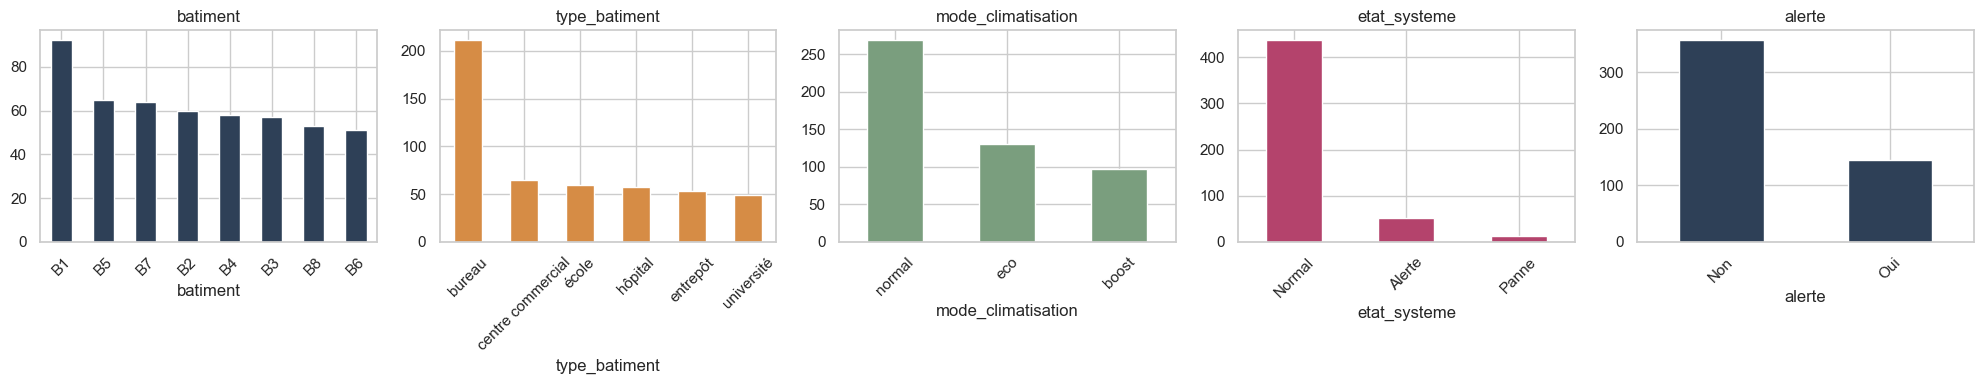

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
# 17a) bâtiments ; 17b) types de bâtiments ; 17c) modes de climatisation ; 17d) états du système ; 17e) classes alerte (dans l'ordre de la liste)
variables_frequence = ["batiment", "type_batiment", "mode_climatisation", "etat_systeme", "alerte"]
for i, colonne in enumerate(variables_frequence):
    df[colonne].value_counts().plot(kind="bar", ax=axes[i], color=PALETTE[i % len(PALETTE)])
    axes[i].set_title(colonne)
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Déséquilibre des classes

*(18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?*

In [23]:
# 18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?
repartition_alerte = df["alerte"].value_counts(normalize=True) * 100
print(repartition_alerte.round(1))

alerte
Non    71.2
Oui    28.8
Name: proportion, dtype: float64


Il y a un **déséquilibre des classes** sur `alerte` (environ 70% / 30%). Il faudra en tenir compte pour le découpage train/test (stratification) et pour le choix du modèle de Machine Learning plus tard.

### Corrélations

*(19) Pour la corrélation sur les variables numériques*

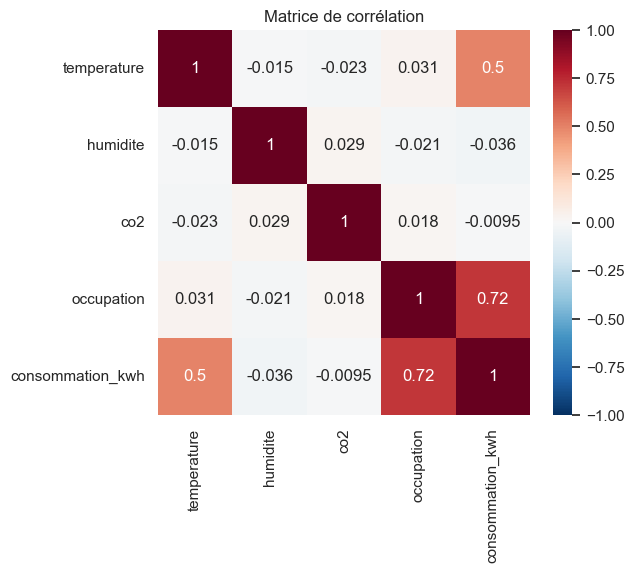

In [24]:
# 19a) visualiser avec seaborn la matrice de corrélation
matrice_correlation = df[colonnes_numeriques].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(matrice_correlation, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()

*(19b) identifier les corrélations positives, négatives et les variables faiblement corrélées*

**Lecture :** `co2` et `occupation` sont positivement corrélées (plus il y a de personnes, plus le CO₂ augmente), `consommation_kwh` est peu corrélée aux autres variables numériques.

## Partie 2 – Séparation X / y

*(1) Définir la variable "alerte" comme la cible y ; (2) Trouver des variables explicatives X pertinentes ; (3) Afficher les cinq premières lignes de X ainsi que de y*

In [25]:
# 1) Définir la variable "alerte" comme la cible y
y = df["alerte"]
# 2) Trouver des variables explicatives X pertinentes
X = df.drop(columns=["alerte", "id_mesure", "date"])

# 3) Afficher les cinq premières lignes de X
X.head()

,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine
0,B8,entrepôt,A,23.0,40.0,851.0,26.0,138.4,eco,Normal,jeudi
1,B7,bureau,D,28.0,69.0,538.0,0.0,170.2,eco,Normal,lundi
2,B5,centre commercial,B,19.5,52.3,1198.0,64.0,149.8,normal,Normal,dimanche
3,B6,université,D,20.0,58.4,1014.0,30.0,141.6,normal,Normal,dimanche
4,B7,bureau,D,26.8,70.5,628.0,42.0,228.3,normal,Normal,jeudi


In [27]:
# 3) Afficher les cinq premières lignes de y
y.head()

0    Non
1    Non
2    Oui
3    Non
4    Non
Name: alerte, dtype: object

## Partie 3 – Découpage Train / Test

*Diviser X en train/test : 20% pour le test, reproductibilité garantie, mêmes proportions de classes (stratification)*

In [28]:
# Diviser X en train/test : 20% pour le test (test_size=0.2), reproductibilité (random_state),
# et mêmes proportions de classes que dans les données d'origine (stratify=y)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)
print(y_train.value_counts(normalize=True).round(2))
print(y_test.value_counts(normalize=True).round(2))

Train : (400, 11)
Test : (100, 11)
alerte
Non    0.71
Oui    0.29
Name: proportion, dtype: float64
alerte
Non    0.71
Oui    0.29
Name: proportion, dtype: float64


## Partie 4 – Encodage des variables catégorielles

*Appliquer, en justifiant, l'encodage le plus adapté à chaque variable catégorielle*

- `batiment`, `type_batiment`, `zone`, `mode_climatisation`, `etat_systeme`, `jour_semaine` sont des variables **nominales** (pas d'ordre naturel) avec un nombre de catégories limité -> **One-Hot Encoding**.
- On aurait pu utiliser un Label Encoding pour `jour_semaine` si un ordre avait du sens, mais ce n'est pas nécessaire ici : on garde le One-Hot Encoding pour toutes les variables catégorielles, ce qui sera fait dans le pipeline (Partie 6).

## Partie 5 – Mise à l'échelle

*(1) Justifier la pertinence de la mise à l'échelle ; (2) Appliquer et justifier une technique de mise à l'échelle ; (3) Pourquoi ne doit-on pas calculer la moyenne et l'écart-type à partir du dataset complet ?*

In [29]:
# 1) A l'aide de quelques variables, justifier la pertinence de la mise à l'échelle
X_train[colonnes_numeriques].agg(["mean", "std"])

,temperature,humidite,co2,occupation,consommation_kwh
mean,23.800518,57.008073,838.164975,45.521739,170.468878
std,3.291658,12.096141,558.102912,24.762956,51.221598


*(1 suite, 2) Appliquer et justifier une technique de mise à l'échelle*

Les variables numériques n'ont pas la même échelle (`co2` va jusqu'à plusieurs milliers, `humidite` reste entre 0 et 100). Beaucoup d'algorithmes (régression logistique, SVM, k-NN...) sont sensibles à ces différences d'échelle : une variable avec de grandes valeurs dominerait le calcul des distances ou des poids. On applique donc un **StandardScaler** (centrage-réduction) sur les variables numériques.

*(3) Pourquoi ne doit-on pas calculer la moyenne et l'écart-type à partir du dataset complet ?*

**Pourquoi ne pas calculer moyenne et écart-type sur le dataset complet ?** Cela ferait fuiter de l'information du jeu de test vers l'entraînement (*data leakage*) : le modèle serait évalué de façon trop optimiste. Le scaler doit être **ajusté (`fit`) uniquement sur le train**, puis appliqué (`transform`) au train et au test.

## Partie 6 – Pipeline de preprocessing

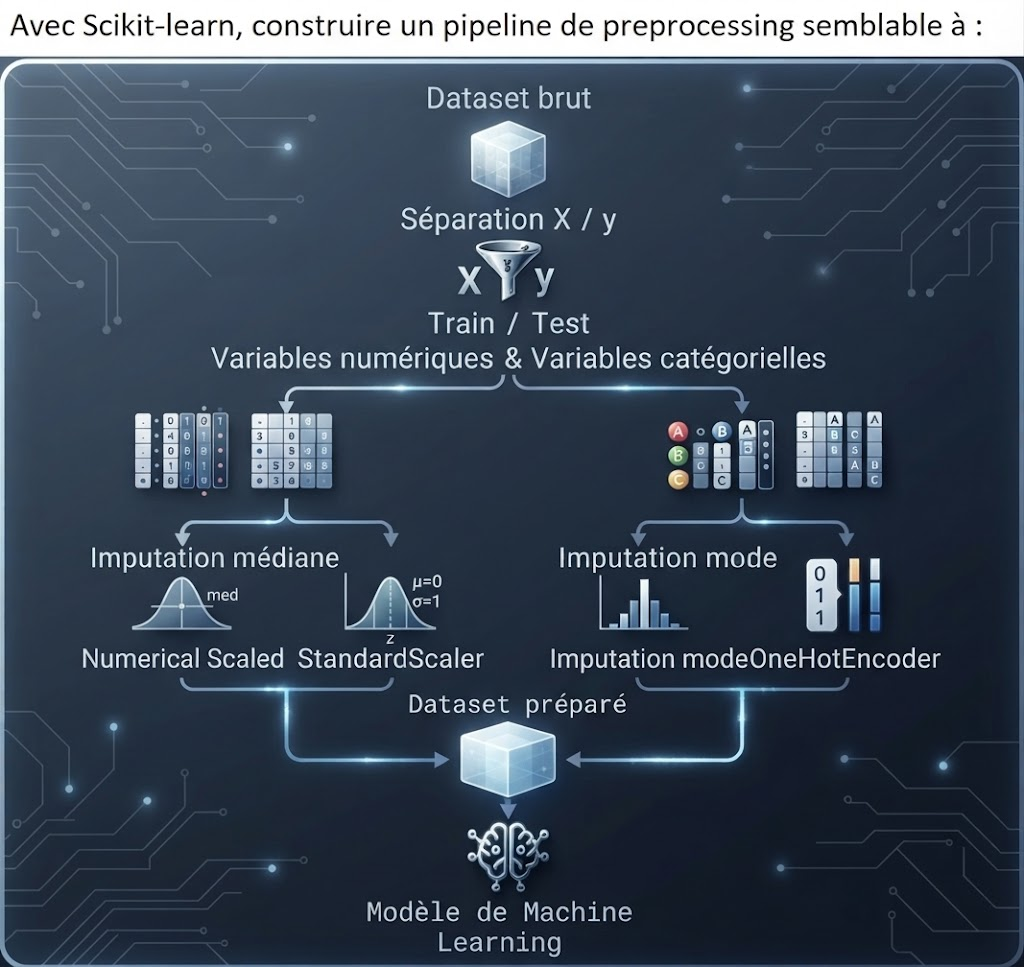

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pipeline_numerique = Pipeline(steps=[
    ("imputation", SimpleImputer(strategy="median")),
    ("mise_a_l_echelle", StandardScaler()),
])

pipeline_categoriel = Pipeline(steps=[
    ("imputation", SimpleImputer(strategy="most_frequent")),
    ("encodage", OneHotEncoder(handle_unknown="ignore")),
])

colonnes_categorielles_X = ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine"]

preprocessing = ColumnTransformer(transformers=[
    ("num", pipeline_numerique, colonnes_numeriques),
    ("cat", pipeline_categoriel, colonnes_categorielles_X),
])

preprocessing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(strategy='median')),
                                                 ('mise_a_l_echelle',
                                                  StandardScaler())]),
                                 ['temperature', 'humidite', 'co2',
                                  'occupation', 'consommation_kwh']),
                                ('cat',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encodage',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['batiment', 'type_batiment', 'zone',
                                  'mode_climatisation', 'etat_systeme',
                                  'jour_semaine'])])

## Partie 7 – Exportation

*Exporter le dataframe nettoyé dans exports/smart_building_cleaned.csv*

In [32]:
# Exporter le dataframe nettoyé dans exports/smart_building_cleaned.csv
df.to_csv("../exports/smart_building_cleaned.csv", index=False)
print("Fichier exporté :", "../exports/smart_building_cleaned.csv")

Fichier exporté : ../exports/smart_building_cleaned.csv


## Partie 8 – Bonus

*Proposer et réaliser toute fonctionnalité pertinente et utile qu'on pourrait rajouter à l'atelier*

Ajout d'une variable dérivée utile pour un futur modèle : la **consommation d'énergie par personne présente** (`consommation_kwh` / `occupation`), un indicateur d'efficacité énergétique plus fin que la consommation brute.

In [33]:
# Bonus : ajout d'une variable dérivée utile (consommation d'énergie par personne présente)
df_bonus = df.copy()
df_bonus["conso_par_personne"] = np.where(
    df_bonus["occupation"] > 0,
    df_bonus["consommation_kwh"] / df_bonus["occupation"],
    np.nan
)
df_bonus[["batiment", "occupation", "consommation_kwh", "conso_par_personne"]].head()

,batiment,occupation,consommation_kwh,conso_par_personne
0,B8,26.0,138.4,5.323077
1,B7,0.0,170.2,NaN
2,B5,64.0,149.8,2.340625
3,B6,30.0,141.6,4.720000
4,B7,42.0,228.3,5.435714
